# 1. Importing all the neccessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import nltk
from nltk.stem import WordNetLemmatizer

In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /Users/vasu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/vasu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/vasu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/vasu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
pwd

'/Users/vasu/Downloads'

In [4]:
cd ./Fractal_test2_datasets/

/Users/vasu/Downloads/Fractal_test2_datasets


In [5]:
ls

sample_submission.csv  test.csv
submissions/           train.csv


# 2. Load the data

In [6]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [7]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (10000, 3)
Test Shape: (4020, 2)


In [8]:
train_df.head()

,ID,Text,Subject
0,train_00001,"Its ""duet"" feature allows users to film a vide...",Pop Culture
1,train_00002,"*@**%%@ To support this, Blizzard released the...",Gaming
2,train_00003,"James Mitchell, the Premier of Western Austral...",History
3,train_00004,Pharo has an implementation of a heap in the C...,Computer Sciences
4,train_00005,"a for Tour, Alberto his his possible allowed m...",Sports


# 3. Data Exploration

In [9]:
print(train_df['Subject'].value_counts())

Sports               2210
Gaming               1640
Pop Culture          1566
Geography            1413
Natural Sciences     1389
Computer Sciences    1039
History               743
Name: Subject, dtype: int64


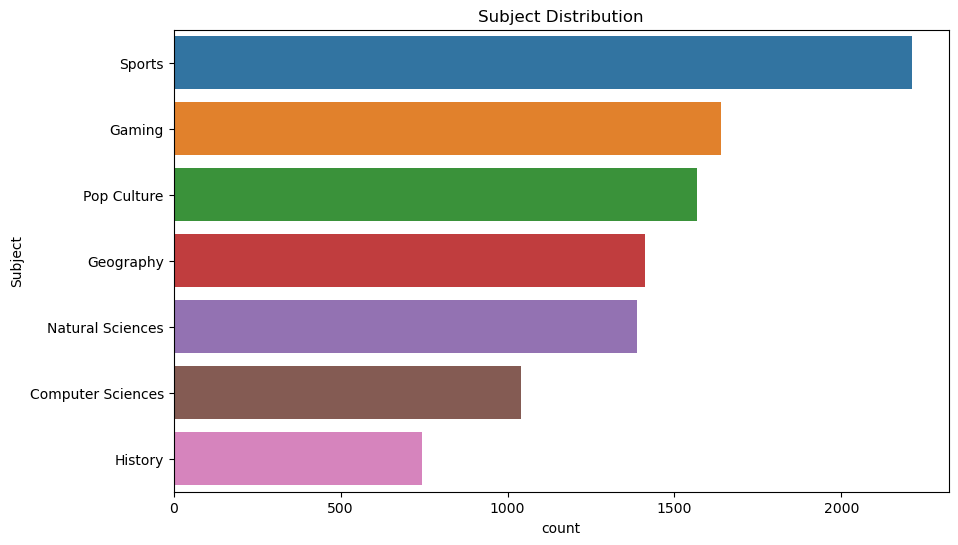

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(y=train_df['Subject'], order=train_df['Subject'].value_counts().index)
plt.title("Subject Distribution")
plt.show()

# 4. Text Preprocessing

In [11]:
lemmatizer = WordNetLemmatizer()

In [12]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Keep letters and numbers, remove other symbols
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Lemmatize but keep all tokens (even stopwords & numbers)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [13]:
# Apply cleaning to train and test
train_df['Clean_Text'] = train_df['Text'].apply(clean_text)
test_df['Clean_Text'] = test_df['Text'].apply(clean_text)

# 5. Train / Validation Split

In [14]:
X = train_df['Clean_Text']
y = train_df['Subject']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Vectorizing the text - Hybrid TF-IDF (Word + Char)

In [15]:
word_vectorizer = TfidfVectorizer(ngram_range=(1,3), analyzer='word', max_df=0.9, min_df=2)
char_vectorizer = TfidfVectorizer(ngram_range=(3,6), analyzer='char', max_df=0.9, min_df=2)

vectorizer = FeatureUnion([
    ('word', word_vectorizer),
    ('char', char_vectorizer)
])

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

# 7. Training the Model - LinearSVC

In [16]:
model = LinearSVC(C=1.0, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced')

# 8. Evaluating on Validation Set

In [17]:
# Here you can see I have used Evaluation metric given for the problem
y_val_pred = model.predict(X_val_tfidf)
val_f1 = f1_score(y_val, y_val_pred, average='macro')
print(f"Validation Macro F1 Score: {val_f1*100:.2f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Validation Macro F1 Score: 88.08

Classification Report:
                   precision    recall  f1-score   support

Computer Sciences       0.89      0.89      0.89       208
           Gaming       0.88      0.87      0.88       328
        Geography       0.88      0.87      0.87       283
          History       0.91      0.87      0.89       148
 Natural Sciences       0.84      0.93      0.88       278
      Pop Culture       0.89      0.82      0.85       313
           Sports       0.89      0.91      0.90       442

         accuracy                           0.88      2000
        macro avg       0.88      0.88      0.88      2000
     weighted avg       0.88      0.88      0.88      2000



# 9. Confusion Matrix

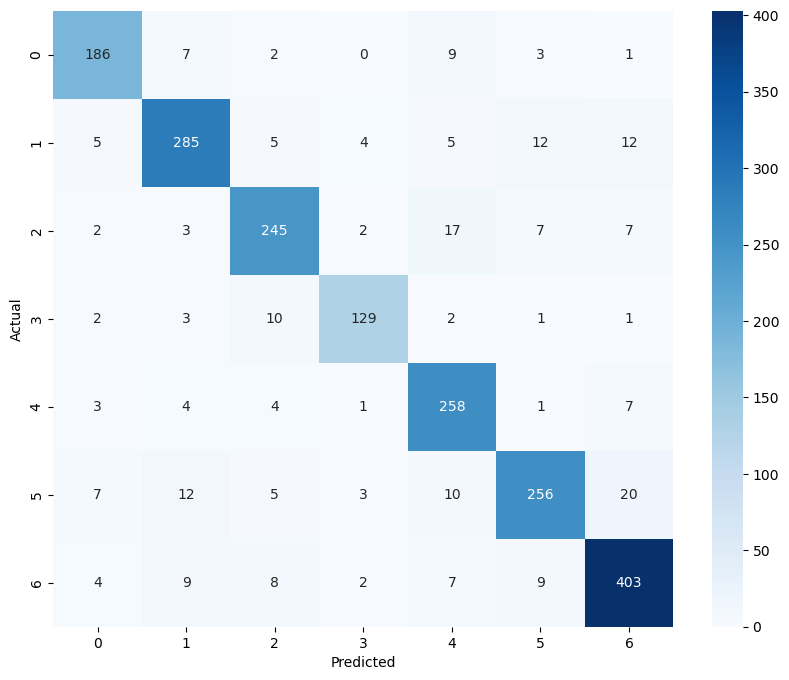

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 10. Training Final model on the training data

In [19]:
X_full_tfidf = vectorizer.fit_transform(train_df['Clean_Text'])
X_test_tfidf = vectorizer.transform(test_df['Clean_Text'])

final_model = LinearSVC(C=1.0, class_weight='balanced')
final_model.fit(X_full_tfidf, y)

LinearSVC(class_weight='balanced')

# 11. Predicting on the given test data

In [20]:
test_predictions = final_model.predict(X_test_tfidf)

# 12. Saving the Results

In [23]:
result_df = pd.DataFrame({
    'ID': test_df['ID'],
    'Subject': test_predictions
})

result_df.to_csv("submission_vasudevsharma.csv", index=False)
print("Prediction file result is successfully saved as submission_vasudevsharma.csv !")

Prediction file result is successfully saved as submission_vasudevsharma.csv !
